
<div align="center">

# Devoir 3
### PHY-7009 – Analyse des signaux (A26)

**Cassandra Mantha**, 537 014 158

**Elias Ouellet-Oviedo**, 537 003 135  

<br><br>

Présenté à **Antoine Godin**

</div>

In [1]:
from __future__ import annotations
from pathlib import Path
import re
import numpy as np
import sys
import io
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg") 

from ics_batch import discover_dataset, analyze_category, summary_table
from ics_plots import (plot_case_overview, plot_density_effect, plot_imagesize_effect,
                        plot_noise_effect, plot_pixelsize_effect, plot_schema,)


from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necessaire pour projection='3d')
from ics_core import crop_center, _gaussian2d

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": False, "grid.alpha": 0.3})
plt.style.use('https://raw.githubusercontent.com/dccote/Enseignement/master/SRC/dccote-basic.mplstyle')

La fonction d'autocorrélation spatiale normalisée $r(\xi, \eta)$ mesure la corrélation des fluctuations entre deux pixels séparés par un décalage spatial (lag) de $\xi$ pixels en $x$ et $\eta$ pixels en $y$ : 
$$r(\xi, \eta) = \frac{\langle \delta i(x, y) \cdot \delta i(x+\xi, y+\eta) \rangle}{\langle i \rangle^2}.$$

Pour accélérer le calcul sur des images entières, on utilise le théorème de Wiener-Khinchin, la transformée de Fourier rapide 2D (FFT) : 
$$r(\xi, \eta) = \frac{\mathcal{F}^{-1}\left( |\mathcal{F}(I(x,y))|^2 \right)}{\langle i \rangle^2} - 1.$$

Pour un système de particules indépendantes, le carré moyen des fluctuations divisé par le carré de l'intensité moyenne est égal à l'inverse du nombre moyen de particules $\langle N \rangle$ présentes dans la tache focale du laser (Beam Area) : 
$$g(0,0) = \frac{1}{\langle N \rangle}.$$

Ainsi, plus la densité d'émetteurs est élevée, plus l'amplitude relative des fluctuations $g(0,0)$ est faible.

Le bruit de photon ou bruit électronique du détecteur est un bruit blanc indépendant d'un pixel à l'autre. Il ne se correle qu'avec lui-même au même pixel, ajoutant une pointe artificielle uniquement au lag central $(0,0)$. En revanche, le signal fluorescent issu de la tache focale (PSF) s'étale sur plusieurs pixels adjacents. En ajustant la fonction par un modèle gaussien 2D en excluant le point central $(0,0)$, on extrapole l'amplitude réelle du signal $g(0,0)$ sans le biais du bruit.

La fonction d'autocorrélation spatiale d'une PSF gaussienne s'écrit : 
$$G(\xi, \eta) = g(0,0) \exp\left( -\frac{\xi^2 + \eta^2}{\omega_{xy}^2} \right) + g_\infty,$$
où $\omega_{xy}$ représente le waist (rayon à $1/e^2$) de la PSF et $g_\infty$ est un décalage asymptotique. Si la taille de pixel est trop grande par rapport à $\omega_{xy}$, le sous-échantillonnage viole le critère de Shannon-Nyquist, déformant le profil gaussien et empêchant l'ajustement correct de la courbe.

In [2]:
BASE_DIR = Path(r"C:\Users\User\OneDrive\Bureau\Université\Maitrise\cours\Analyse des signaux\Projets\Projet 3\ICS_analysis\simulations")          # dossier racine fourni par l'enseignant
OUTPUT_DIR = Path("resultats_ICS")      # où ecrire les figures / tableaux

PIXEL_SIZE_UM_DEFAULT = 0.05            # taille de pixel nominale (µm/pixel)
PSF_OMEGA_UM = 0.2                      # rayon 1/e^2 nominal de la PSF (µm)
DEFAULT_DENSITY_PER_BA = 10             # densite nominale par defaut (part./beam area)


NOMINAL_DENSITIES: dict[str, float] = {}

# Taille de pixel (µm) 
def pixel_size_from_case_name(name: str, fallback: float = PIXEL_SIZE_UM_DEFAULT) -> float:
    m = re.search(r"[\d.]+", name)
    return float(m.group()) if m else fallback


# Parametres d'ajustement (fenetre centrale conservee pour le fit gaussien,
#  en pixels ; fraction minimale de recouvrement requise pour garder un lag)
FIT_HALF_WIDTH = 15
MIN_OVERLAP_FRAC = 0.3

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

base_dir = BASE_DIR
dataset = discover_dataset(base_dir)

# Schema conceptuel
plot_schema(psf_omega_um=PSF_OMEGA_UM, pixel_size_um=PIXEL_SIZE_UM_DEFAULT, savepath=OUTPUT_DIR / "00_schema_parametres.png")

all_summaries = {}

### A) Simulateur : Image correlation spectroscopy (ICS)

##### A.1) La densité des particules

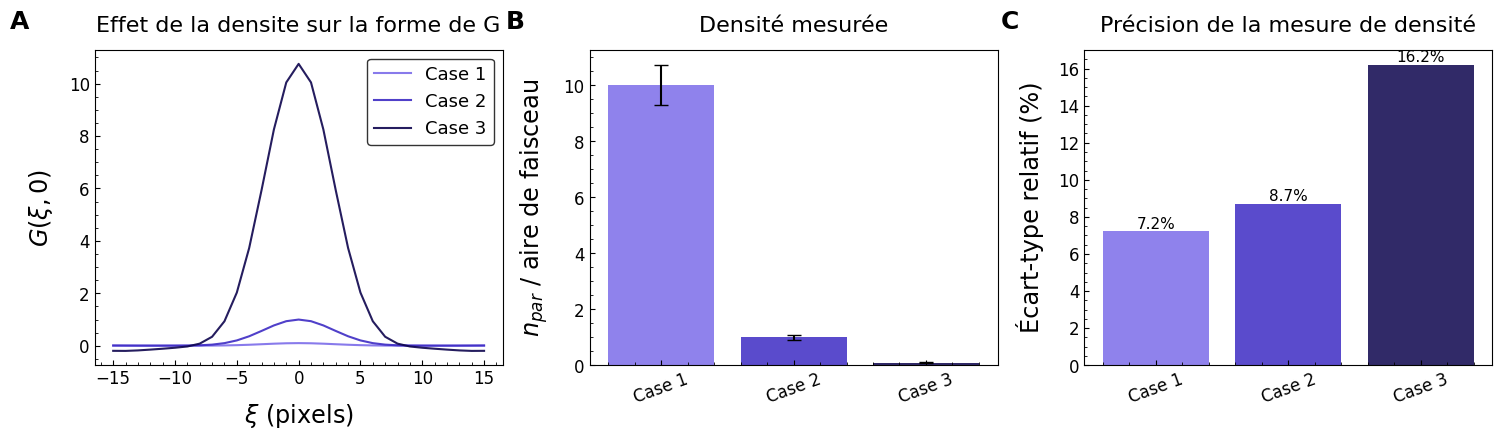

In [3]:
if "density" in dataset:
    res = analyze_category(dataset["density"], pixel_size_um=PIXEL_SIZE_UM_DEFAULT,
                            fit_half_width=FIT_HALF_WIDTH, min_overlap_frac=MIN_OVERLAP_FRAC)
    for case, r in res.items():
        plot_case_overview(r, f"Densite - {case}",
                            savepath=OUTPUT_DIR / f"01_density_overview_{case.replace(' ', '_')}.png")

    fig = plot_density_effect(res, nominal=NOMINAL_DENSITIES or None,
                            savepath=OUTPUT_DIR / "01_density_effect_summary.png")
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)

    df = summary_table(res, nominal=NOMINAL_DENSITIES or None)
    df.to_csv(OUTPUT_DIR / "01_density_summary.csv", index=False)
    all_summaries["density"] = df

<!-- À partir des images fournies, étudiez l’effet des différents paramètres suivants sur la fonction 
d’autocorrélation spatiale et sur la précision de l’estimation de la densité de particules : 
• La densité des particules (0.1 to 10 émetteurs / surface effective du laser (pi*wxy2)). -->

$\textbf{A)}$ L'effet de la densité sur la forme de la fonction de corrélation est étudiée. La spectroscopie de corrélation d'image mesure l'amplitude des fluctuations relatives de fluorescence $ \delta I / \langle I \rangle$ autour de l'intensité moyenne. Pour des particules indépendantes, l'amplitude de la fonction d'autocorrélation au lag zéro $g(0,0)$ est égale à l'inverse du nombre moyen d'émetteurs $\langle N \rangle$ présents dans la surface effective du laser ($\text{Beam Area} = \pi \cdot \omega_{xy}^2$). Ainsi, une plus grande densité engendre une valeur $g(0,0)$ plus faible. En effet, il est observé que, pour le cas 1, présentant une densité théorique $\langle N \rangle_{\text{théo}} = 10,0$, $g(0,0) = 0,0998$. Le cas 2 présentant une densité théorique $\langle N \rangle_{\text{théo}} = 1,0$, $g(0,0) = 0,9938$. Le cas 3 présentant une densité théorique $\langle N \rangle_{\text{théo}} = 0,1$, $g(0,0) = 10,7$. Lorsque la densité augmente de $0,1$ à $10$ particules/BA, l'amplitude $g(0,0)$ diminue de deux ordres de grandeur (passant de $\sim 10$ à $\sim 0,1$). Une image très dense apparaît visuellement plus lisse et homogène, ce qui réduit la variance spatiale relative.

Il est également observé que la largeur spatiale de la Gaussienne d'autocorrélation (le paramètre $w_0$) reste constante. La largeur dépend uniquement des propriétés optiques du microscope (la tache de diffraction PSF) et non de la quantité de fluorophores observés.

$\textbf{B)}$ Les densités sont mesurées à partir des $g(0,0)$ obtenus. Pour le cas 1, $\langle N \rangle_{\text{estimé}} = 10,0 \pm 0,7$, pour le cas 2 $\langle N \rangle_{\text{estimé}} = 1,01 \pm 0,09$ et pour le cas 3, $\langle N \rangle_{\text{estimé}} = 0,09 \pm 0,02$. L'estimation de la densité est juste et non biaisée sur 3 ordres de grandeur.

$\textbf{C)}$ Une analyse de la précision sur les mesures de densité est effectuée afin de déterminer la tendance. Il est possible d'observer qu'à faible densité ($\langle N \rangle = 0,1$), l'amplitude de fluctuation est forte ($g_0 \approx 10$), mais le nombre restreint d'émetteurs dans l'image augmente l'incertitude relative de mesure d'une image à l'autre. À forte densité ($\langle N \rangle = 10,0$), l'échantillonnage spatial est plus représentatif, stabilisant l'incertitude relative de l'estimation ($\sim 7,2\,\%$).


##### A.2) La durée de la simulation

En ICS spatiale, la durée de la simulation définit la surface de la région générée. Cette taille est mesurée en multiples de la surface du faisceau laser ($\text{Beam Area} = \pi \cdot \omega_{xy}^2$). L'ICS extrait ses paramètres en réalisant une moyenne spatiale des fluctuations d'intensité sur l'ensemble des pixels de l'image. Analyser une image plus grande revient à augmenter le nombre d'échantillons spatiaux indépendants (le nombre de Beam Areas) observés simultanément.

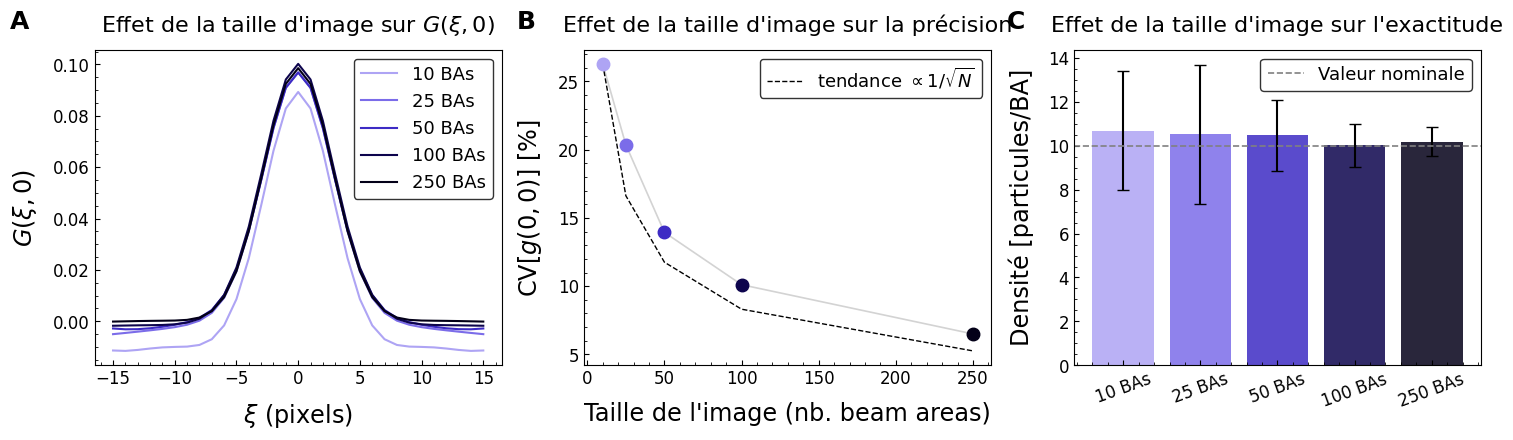

In [4]:
size_key = "image size" if "image size" in dataset else "imagesize"
if size_key in dataset:
    res = analyze_category(dataset[size_key], pixel_size_um=PIXEL_SIZE_UM_DEFAULT,
                            fit_half_width=FIT_HALF_WIDTH, min_overlap_frac=MIN_OVERLAP_FRAC)
    for case, r in res.items():
        hw = min(FIT_HALF_WIDTH, r["Gavg"].shape[0] // 2 - 1)
        plot_case_overview(r, f"Taille d'image - {case}",
                            savepath=OUTPUT_DIR / f"02_imagesize_overview_{case.replace(' ', '_')}.png",
                            half_width_display=hw)
    fig = plot_imagesize_effect(res, nominal_n_per_BA=DEFAULT_DENSITY_PER_BA or None,
                            savepath=OUTPUT_DIR / "02_imagesize_effect_summary.png")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)

    df = summary_table(res)
    df.to_csv(OUTPUT_DIR / "02_imagesize_summary.csv", index=False)
    all_summaries["image_size"] = df

<!-- À partir des images fournies, étudiez l’effet des différents paramètres suivants sur la fonction 
d’autocorrélation spatiale et sur la précision de l’estimation de la densité de particules : 
• La durée de la simulation. Montrez comment la taille de l’image influence la précision. -->

<!--
10 BAs : $\text{Mean } g(0,0) = 0,0995 \implies \langle N \rangle_{\text{estimé}} = 10,70$
25 BAs : $\text{Mean } g(0,0) = 0,1002 \implies \langle N \rangle_{\text{estimé}} = 10,54$
50 BAs : $\text{Mean } g(0,0) = 0,0974 \implies \langle N \rangle_{\text{estimé}} = 10,49$
100 BAs : $\text{Mean } g(0,0) = 0,1006 \implies \langle N \rangle_{\text{estimé}} = 10,03$
250 BAs : $\text{Mean } g(0,0) = 0,0986 \implies \langle N \rangle_{\text{estimé}} = 10,18$
-->

<!--
10 BAs : Écart-type $\sigma_{\langle N \rangle} = 2,70$ (soit $\sim 25,4\,\%$ d'incertitude relative).
25 BAs : $\sigma_{\langle N \rangle} = 3,17$.
50 BAs : $\sigma_{\langle N \rangle} = 1,62$.
100 BAs : $\sigma_{\langle N \rangle} = 0,97$.
250 BAs : $\sigma_{\langle N \rangle} = 0,65$ (soit $\sim 6,4\,\%$ d'incertitude relative).
-->

$\textbf{A)}$ Une analyse sur l'effet de la taille de l'image sur la fonction de corrélation est faite. Une petite image (faible nombre de Beam Areas) présente une plus grande probabilité de chevauchements aléatoires à grand décalage spatial, ce qui génère des pics de corrélation parasites dans la région où la fonction devrait décroître vers le fond asymptotique $g_\infty$. Ces fluctuations perturbent l'ajustement du paramètre $g_\infty$, augmentant fortement la variance et l'incertitude statistique de l'estimation de la densité ($\sigma_{\langle N \rangle}$). À l'inverse, une grande image offre une région $g_\infty$ lisse et un fond stable grâce à la loi des grands nombres, garantissant des ajustements stables et une incertitude de mesure minimale.

$\textbf{B)}$ Une analyse de l'influence de la taille de l'image révèle que celle-ci affecte la précision de la mesure. En effet, le coefficient de variation de $g(0,0)$ est analysé. Ce dernier correspond à l'écart-type $\sigma_{g_0}$ entre répétitions, normalisé par sa moyenne $\mu_{g_0}$, exprimé en pourcentage, tel que :
$$CV[g(0, 0)] = 100 \times \frac{\mu_{g_0}}{\sigma_{g_0}} [\%].$$
Selon le théorème central limite, la variance d'estimation des fluctuations diminue de manière inversement proportionnelle à la surface d'analyse : 
$$\sigma_{\langle N \rangle} \propto \frac{1}{\sqrt{\text{Nombre de BAs}}}.$$

Une diminution du CV avec l'augmentation de N est observée (de ~26% à 10 BAs jusqu'à ~6.5% à 250 BAs). Cette tendance correspond aux prédictions théorique; plus l'image est grande, plus la mesure de $g(0,0)$ est précise d'une répétition à l'autre. Une sur-estimation de l'erreur est tout de même observée, indiquant la présence d'une source de bruit supplémentaire à l'erreur statistique.

$\textbf{C)}$ La taille de l'image n'influence pas de façon significative la densité esitmée à l'aide de la méthode ICS. En effet, la densité moyenne estimée pour l'ensemble des taille correspond à la valeur théorique attendue de 10 particules/BA (soit $g(0,0) = 0,10$). Il est tout de même possible d'observer une légèrement sur-estimation pour les tailles plus petites. L'écart-type passe de $\sigma_{\langle N \rangle} = 2,70$ pour 10 BAs à $\sigma_{\langle N \rangle} = 0,65$ pour 250 BAs. Cela représente une diminution de l'incertitude d'environ un facteur 4, concordant avec les observations effectuées en B.


##### A.3) Discutez comment le bruit du détecteur (Shot noise) influence $G(\xi, \nu)$.

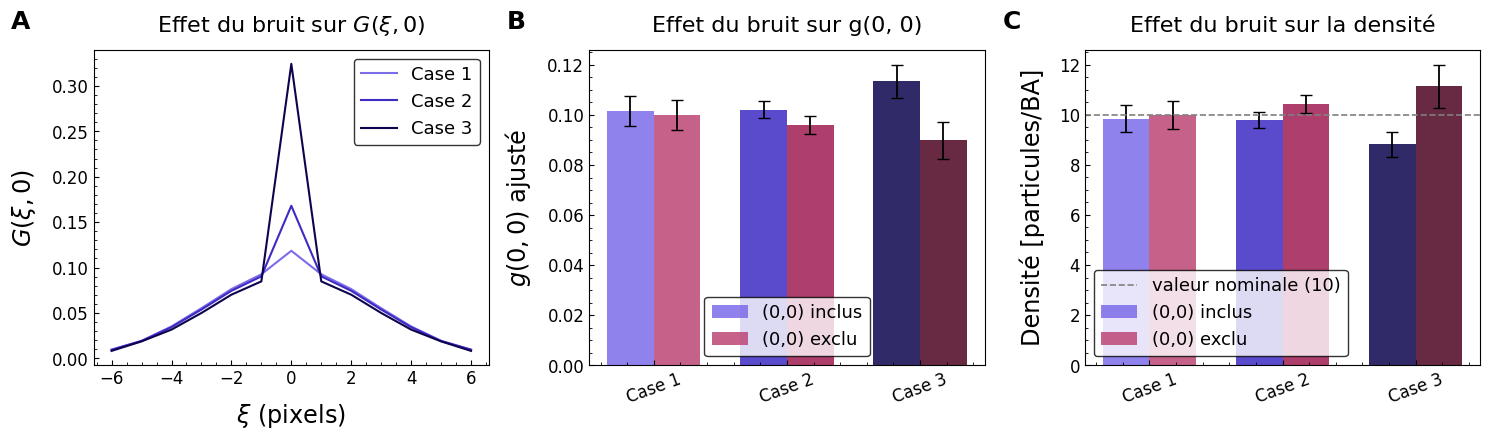

In [5]:
if "noise" in dataset:
    res = analyze_category(dataset["noise"], pixel_size_um=PIXEL_SIZE_UM_DEFAULT,
                            fit_half_width=FIT_HALF_WIDTH, min_overlap_frac=MIN_OVERLAP_FRAC)
    for case, r in res.items():
        plot_case_overview(r, f"Bruit - {case}",
                            savepath=OUTPUT_DIR / f"03_noise_overview_{case.replace(' ', '_')}.png")
    fig = plot_noise_effect(res, savepath=OUTPUT_DIR / "03_noise_effect_summary.png")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)

    df = summary_table(res)
    df.to_csv(OUTPUT_DIR / "03_noise_summary.csv", index=False)
    all_summaries["noise"] = df

$\textbf{A)}$ Le bruit de photon (shot noise) et le bruit électronique du détecteur (ex. PMT ou caméra CCD) sont des bruits blancs spatio-temporellement non corrélés entre pixels voisins. Contrairement au bruit, la fluorescence émise par les fluorophores est étalée sur plusieurs pixels adjacents en raison de la tache de diffraction du microscope (la PSF). Le signal biologique possède donc une corrélation spatiale que le bruit n'a pas.

Le bruit du détecteur n'est pas corrélé avec lui-même à l'exception du même pixel spatial et temporel, le lag central. Cela fait en sorte qu'un pic au point (0, 0) apparait dans la fonction de corrélation $G(\xi, \eta)$. Seul ce point est affecté par le bruit blanc, tous les autres points reflètent uniquement la corrélation spatiale réelle introduite par la PSF.

$\textbf{B)}$ L'effet du bruit du détecteur sur l'ajustement de la fonction de corrélation a été analysé. Deux cas ont été comparés pour l'ensemble des niveaux de bruit, un avec prise en compte du point (0, 0), puis un second avec son exclusion. Lorsque ce point est inclus, une surestimation de plus en plus marquée apparaît à mesure que le bruit augmente, ce qui est cohérent avec l'augmentation de l'amplitude du pic de bruit au lag zéro. À l'inverse, l'exclusion de ce point permet d'atténuer cette surestimation, voir inverser la tendance observée.

$\textbf{C)}$ L'impact de la prise en compte du bruit se manifeste clairement dans les résultats. Pour le premier niveau de bruit (Cas 1), l'exclusion du lag (0, 0) corrige efficacement le shot noise, permettant de retrouver la densité théorique attendue ($\langle N \rangle_{\text{exclu}} = 10{,}0 \pm 0{,}6$). En revanche, à très fort bruit (Cas 3), la méthode avec exclusion présente un biais résiduel (+11,4 %), orienté dans le sens opposé au cas où le lag est inclus. Cette surestimation de la densité $\langle N \rangle$ met en évidence les limites de cette correction. À fort niveau de bruit, le rapport signal/bruit global de la fonction de corrélation se dégrade. L'extrapolation de $g(0,0)$ devient plus instable car les points adjacents (lags ±1, ±2...) subissent eux-mêmes une forte incertitude, un effet amplifié par le faible nombre de répétitions (10 images). L'augmentation de l'écart-type inter-répétitions entre le cas 2 et le cas 3 (de 0,37 à 0,86) confirme ainsi une dégradation simultanée de la précision et de l'exactitude de la mesure. 

<!--
Noise Case 1 : $\langle N \rangle_{\text{exclu}} = 10,00 \pm 0,56$ et $\langle N \rangle_{\text{inclu}} = 9,84 \pm 0,54$
Noise Case 2 : $\langle N \rangle_{\text{exclu}} = 10,42 \pm 0,37$ et $\langle N \rangle_{\text{inclu}} = 9,80 \pm 0,32$
Noise Case 3 : $\langle N \rangle_{\text{exclu}} = 11,14 \pm 0,86$ et $\langle N \rangle_{\text{inclu}} = 8,81 \pm 0,51$
-->

##### A.4) La taille du pixel

c:\Users\User\OneDrive\Bureau\Université\Maitrise\cours\Analyse des signaux\Projets\Projet 3\ICS_analysis\ics_core.py:177: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(_gaussian2d, xdata, ydata, p0=p0, maxfev=20000)


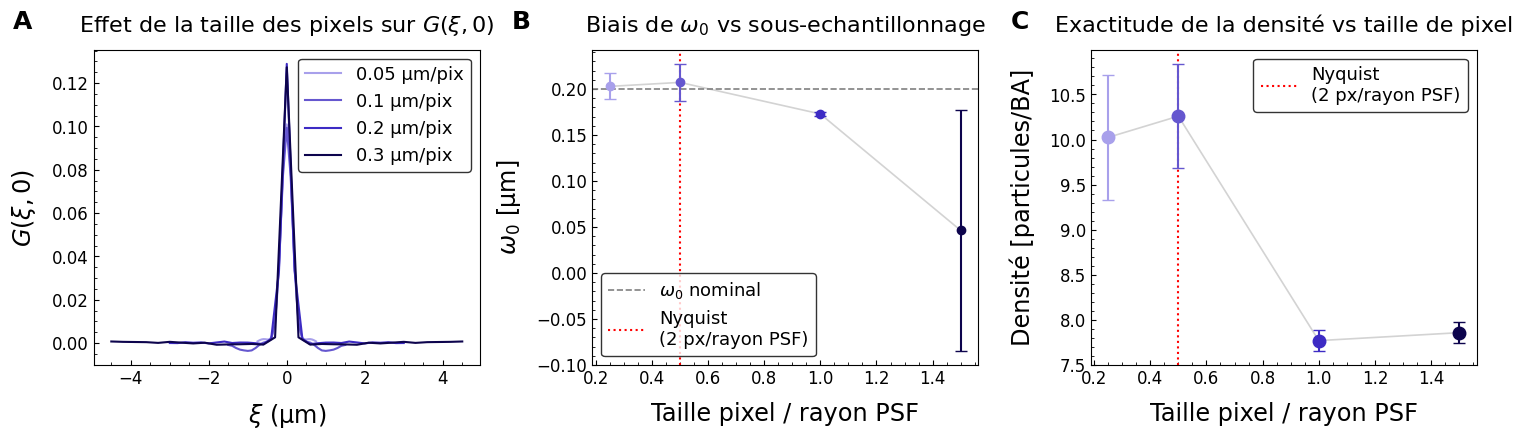

In [6]:
ps_key = "pixel size" if "pixel size" in dataset else "pixelsize"
if ps_key in dataset:
    cases = dataset[ps_key]
    pixel_size_map = {c: pixel_size_from_case_name(c) for c in cases}
    res = analyze_category(cases, pixel_size_um=pixel_size_map,
                            fit_half_width=FIT_HALF_WIDTH, min_overlap_frac=MIN_OVERLAP_FRAC)
    for case, r in res.items():
        hw = min(FIT_HALF_WIDTH, r["Gavg"].shape[0] // 2 - 1)
        plot_case_overview(r, f"Taille de pixel - {case}",
                            savepath=OUTPUT_DIR / f"04_pixelsize_overview_{case.replace(' ', '_')}.png",
                            half_width_display=hw)
    fig = plot_pixelsize_effect(res, nominal_omega_um=PSF_OMEGA_UM,
                            savepath=OUTPUT_DIR / "04_pixelsize_effect_summary.png")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)

    df = summary_table(res)
    df.to_csv(OUTPUT_DIR / "04_pixelsize_summary.csv", index=False)
    all_summaries["pixel_size"] = df


$\textbf{A)}$ En ICS, l'outil permettant de déterminer la fonction de corrélation est le faisceau laser, représenté par la fonction d'étalement de point (PSF) de rayon $w_0$. Pour pouvoir ajuster correctement une fonction gaussienne 2D sur la fonction d'autocorrélation $G(\xi, \eta)$, il est nécessaire de disposer d'un nombre suffisant de points (pixels) le long de la pente de décroissance de la PSF. Pour une analyse ICS classique, la taille de pixel optimale se situe généralement entre $0,05$ et $0{,}10\,\mu\text{m/pixel}$. Cela garantit qu'au moins 5 à 10 pixels échantillonnent le profil de la tache focale.

Lorsque la taille de pixel devient trop grande par rapport au rayon $w_0$ du laser (sous-échantillonnage / aliasing), il y a une perte de résolution du profil gaussien. La tache focale du laser s'étale sur seulement 1 ou 2 pixels au lieu de plusieurs. Les lags spatiaux adjacents ($\xi = 1, 2...$) mesurent des régions déjà disjointes.

La fonction d'autocorrélation perd sa forme gaussienne et s'écrase sous la forme d'un pic très étroit qui chute immédiatement au niveau du fond dès le lag $\xi = 1$. Cela s'explique par le fait que l'algorithme d'ajustement ne dispose plus d'assez de points sur les pentes pour estimer la largeur $w_0$ ni pour extrapoler le sommet $g(0,0)$, on ne respecte plus le théorème d'échantillonnage de Nyquist.

$\textbf{B)}$ - $\textbf{C)}$ Pour des pixels de $0,05$ à $0,10~\rm{\mu m}$, la PSF est correctement échantillonnée. Les deux paramètres physiques ($\omega_0$ et $N$) sont retrouvés avec une erreur inférieure à 3%. Pour des pixel de $0,20~\rm{\mu m}$, $G(\xi, \eta)$ n'est plus décrite que par un point central et un ou deux points de décroissance, ce qui fait en sorte que la forme gaussienne devient impossible à ajuster correctement. Ainsi, $\omega_0$ est sous-estimé de 14 % et $N$ est sous-estimé de 22 %. Pour des pixel de $0,30~\rm{\mu m}$, le pixel est plus large que le rayon de la PSF. $G(\xi, \eta)$ s'effondre quasiment en un pic isolé au lag (0,0), sans décroissance exploitable sur plusieurs pixels. 

<!-- À partir des images fournies, étudiez l’effet des différents paramètres suivants sur la fonction 
d’autocorrélation spatiale et sur la précision de l’estimation de la densité de particules : 
• La taille du pixel. Montrez ce qui se passe sur la fonction de corrélation spatiale si la taille 
du pixel est trop grande par rapport au rayon de la PSF.  -->


### B) Simulateur : Raster Image correlation spectroscopy (RICS)
<!-- Avec la série d’images de particules qui diffusant sur le plan montrez que le coefficient de diffusion de 
particules qui diffusant rapidement influence G(). -->

• Le coefficient de diffusion (de 0.1 à 100 µm2/s) des particules, Discuter comment les paramètres du microscope influencent les corrélations dans l’axe rapide et lent du balayage